<a href="https://colab.research.google.com/github/arinamartynyuk/qwerty/blob/main/%D0%9B%D0%B0%D0%B14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                 date  Кількість відвідувачів музеїв, \nмлн. осіб
0                 NaT                                         NaN
1 1990-01-01 03:00:00                                        31.8
2 1991-01-01 02:00:00                                        20.8
3 1992-01-01 02:00:00                                        16.3
4 1993-01-01 02:00:00                                        18.0
(29, 2)
date                                          datetime64[ns]
Кількість відвідувачів музеїв, \nмлн. осіб           float64
dtype: object
date                                          1
Кількість відвідувачів музеїв, \nмлн. осіб    1
dtype: int64
0
                                date  visitors_mln         year
count                             28     28.000000    28.000000
mean   2003-07-02 20:02:08.571428608     18.678571  2003.500000
min              1990-01-01 03:00:00     14.200000  1990.000000
25%              1996-10-01 14:00:00     16.225000  1996.750000
50%              2003-07-02 1

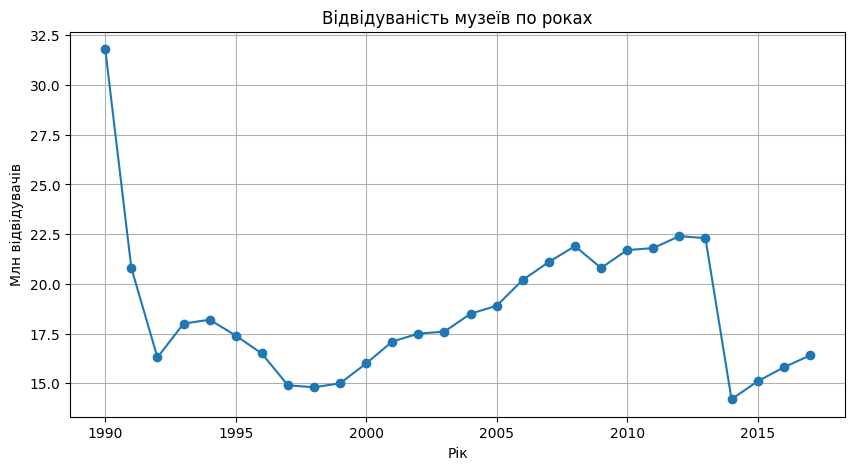

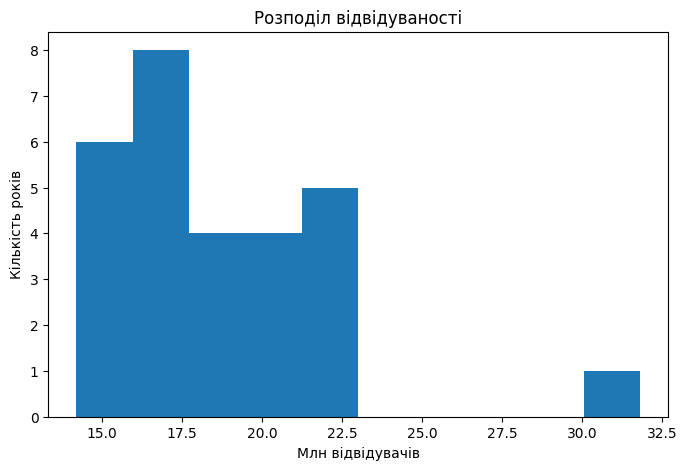

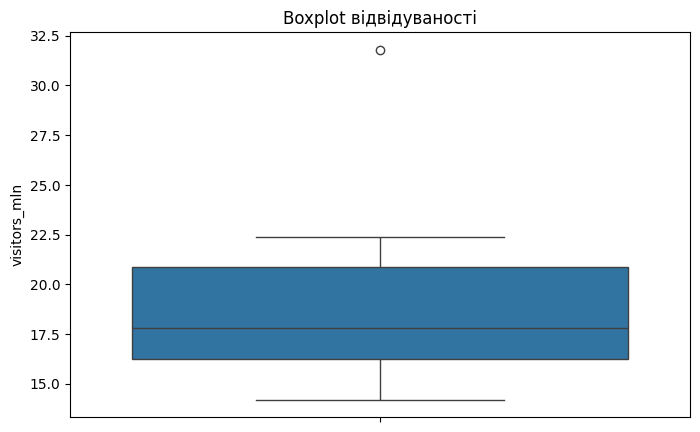

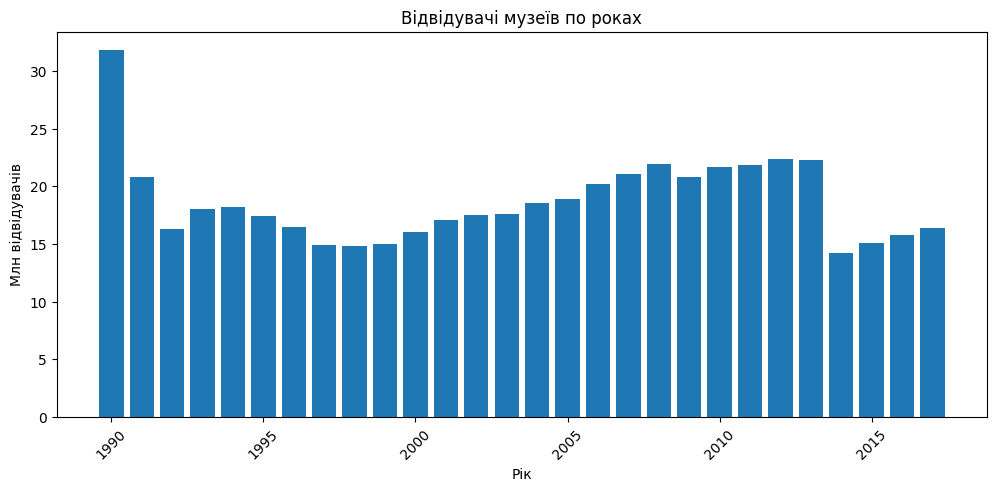

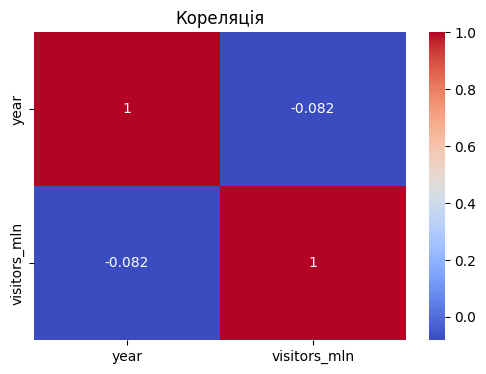

In [2]:
# Лабораторна робота 4
# Глибокий аналіз і візуалізація даних

# Імпортуємо бібліотеки
import pandas as pd              # робота з таблицями
import numpy as np               # числові обчислення
import matplotlib.pyplot as plt  # графіки
import seaborn as sns            # красиві графіки

# Завантажуємо таблицю
df = pd.read_excel('undefined.xlsx')   # читаємо Excel файл

# Показуємо перші 5 рядків
print(df.head())                # перші записи таблиці

# Загальна інформація
print(df.shape)                 # кількість рядків і стовпців
print(df.dtypes)                # типи даних
print(df.isnull().sum())        # кількість пропусків

# Видаляємо порожній перший рядок
df = df.dropna()                # прибираємо пусті рядки

# Перевірка дублікатів
print(df.duplicated().sum())    # кількість дублікатів

# Якщо є дублікати — видаляємо
df = df.drop_duplicates()       # прибираємо повтори

# Перейменовуємо стовпці
df.columns = ['date', 'visitors_mln']   # короткі назви колонок

# Перетворюємо дату
df['date'] = pd.to_datetime(df['date'])   # дата у формат datetime

# Додаємо рік
df['year'] = df['date'].dt.year   # окремо рік

# Основна статистика
print(df.describe())            # середнє, мін, макс

# Мінімальне значення
print("Мінімум:")
print(df.loc[df['visitors_mln'].idxmin()])

# Максимальне значення
print("Максимум:")
print(df.loc[df['visitors_mln'].idxmax()])

# ---------------- ГРАФІКИ ----------------

# Лінійний графік
plt.figure(figsize=(10,5))      # розмір
plt.plot(df['year'], df['visitors_mln'], marker='o')   # лінія
plt.title('Відвідуваність музеїв по роках')   # назва
plt.xlabel('Рік')               # підпис X
plt.ylabel('Млн відвідувачів')  # підпис Y
plt.grid(True)                  # сітка
plt.show()

# Гістограма
plt.figure(figsize=(8,5))
plt.hist(df['visitors_mln'], bins=10)
plt.title('Розподіл відвідуваності')
plt.xlabel('Млн відвідувачів')
plt.ylabel('Кількість років')
plt.show()

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(y=df['visitors_mln'])
plt.title('Boxplot відвідуваності')
plt.show()

# Barplot
plt.figure(figsize=(12,5))
plt.bar(df['year'], df['visitors_mln'])
plt.title('Відвідувачі музеїв по роках')
plt.xlabel('Рік')
plt.ylabel('Млн відвідувачів')
plt.xticks(rotation=45)
plt.show()

# Heatmap кореляції
plt.figure(figsize=(6,4))
sns.heatmap(df[['year','visitors_mln']].corr(), annot=True, cmap='coolwarm')
plt.title('Кореляція')
plt.show()

# ВИСНОВОК:
# Було проведено аналіз таблиці відвідуваності музеїв.
# Дані очищено від пропусків і дублікатів.
# Побудовано графіки, які показали зміну кількості відвідувачів по роках.
# Можна зробити висновок, що відвідуваність змінювалась нерівномірно.